In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
#data loading 
ticker1 = "HDFCBANK.NS"
ticker2 = "ICICIBANK.NS"

start_date = "2015-03-01"
end_date = "2026-09-19"

data1 = yf.download(ticker1, start=start_date, end=end_date)
data2 = yf.download(ticker2, start=start_date, end=end_date)

df = pd.DataFrame()
df[ticker1] = data1["Close"]
df[ticker2] = data2["Close"]

print(df.head())
print(df.shape)
print(df.isna().sum())


[*********************100%***********************]  1 of 1 completed


In [3]:
#data normalization
first_value_of_column = df["HDFCBANK.NS"].iloc[0]
normalized_column1 = df["HDFCBANK.NS"] / first_value_of_column

second_value_of_column = df["ICICIBANK.NS"].iloc[0]
normalized_column2 = df["ICICIBANK.NS"] / second_value_of_column




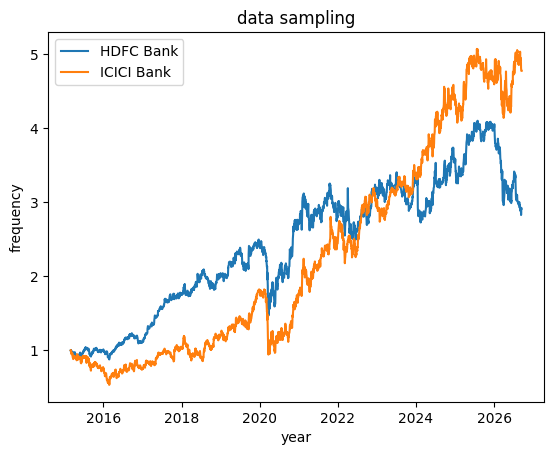

In [4]:
plt.plot(normalized_column1, label="HDFC Bank")
plt.plot(normalized_column2, label="ICICI Bank")
plt.title('data sampling')
plt.xlabel('year')
plt.ylabel('frequency')
plt.legend()
plt.savefig("data sampling.png")
plt.show()


In [5]:
#simple linier regration 
slope = np.polyfit(df["HDFCBANK.NS"] ,df["ICICIBANK.NS"] ,1)

hedge_ratio = slope[0]
intercept = slope[1]



In [6]:
slope

array([   1.71863241, -357.77348297])

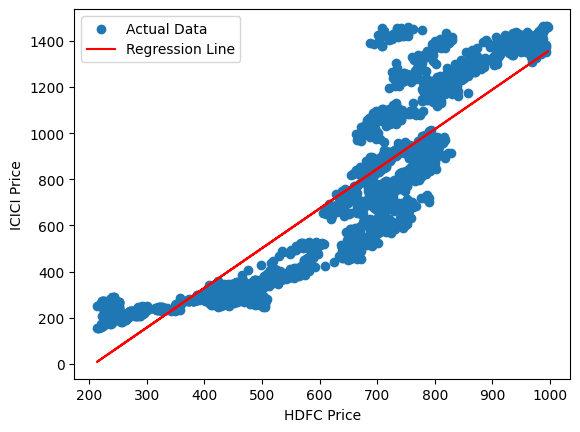

In [7]:
plt.scatter(df["HDFCBANK.NS"], df["ICICIBANK.NS"], label="Actual Data")
predicted_icici = hedge_ratio * df["HDFCBANK.NS"] + intercept
plt.plot(df["HDFCBANK.NS"], predicted_icici, color="red", label="Regression Line")
plt.xlabel("HDFC Price")
plt.ylabel("ICICI Price")
plt.legend()
plt.savefig("Regration line.png")
plt.show()


In [8]:
df["spread"] = df[ticker1] - (hedge_ratio * df[ticker2])
print(df["spread"].head())

Date
2015-03-02   -253.478357
2015-03-03   -252.729906
2015-03-04   -257.777148
2015-03-05   -251.056884
2015-03-09   -235.651404
Name: spread, dtype: float64


In [9]:
#mean and median 
df["spread_mean"] = df["spread"].rolling(window=20).mean()
df["spread_std"] = df["spread"].rolling(window=20).std()

print(df[["spread", "spread_mean", "spread_std"]].head(25))


                spread  spread_mean  spread_std
Date                                           
2015-03-02 -253.478357          NaN         NaN
2015-03-03 -252.729906          NaN         NaN
2015-03-04 -257.777148          NaN         NaN
2015-03-05 -251.056884          NaN         NaN
2015-03-09 -235.651404          NaN         NaN
2015-03-10 -238.308148          NaN         NaN
2015-03-11 -236.010259          NaN         NaN
2015-03-12 -244.319723          NaN         NaN
2015-03-13 -235.623176          NaN         NaN
2015-03-16 -235.403423          NaN         NaN
2015-03-17 -238.780384          NaN         NaN
2015-03-18 -237.474721          NaN         NaN
2015-03-19 -233.479575          NaN         NaN
2015-03-20 -216.149723          NaN         NaN
2015-03-23 -211.151825          NaN         NaN
2015-03-24 -210.649147          NaN         NaN
2015-03-25 -218.591444          NaN         NaN
2015-03-26 -211.989223          NaN         NaN
2015-03-27 -219.648459          NaN     

In [10]:
print(type(df))
print(df.head())

<class 'pandas.core.frame.DataFrame'>
            HDFCBANK.NS  ICICIBANK.NS      spread  spread_mean  spread_std
Date                                                                      
2015-03-02   242.993469    288.876099 -253.478357          NaN         NaN
2015-03-03   243.172958    288.545044 -252.729906          NaN         NaN
2015-03-04   239.121399    289.124390 -257.777148          NaN         NaN
2015-03-05   243.565765    287.800140 -251.056884          NaN         NaN
2015-03-09   237.707260    275.427521 -235.651404          NaN         NaN


In [11]:
#main part Z_score calculation 
df["z_score"] = (df["spread"] - df["spread_mean"]) / df["spread_std"]
print(df[["spread", "spread_mean", "spread_std", "z_score"]].head(25))

                spread  spread_mean  spread_std   z_score
Date                                                     
2015-03-02 -253.478357          NaN         NaN       NaN
2015-03-03 -252.729906          NaN         NaN       NaN
2015-03-04 -257.777148          NaN         NaN       NaN
2015-03-05 -251.056884          NaN         NaN       NaN
2015-03-09 -235.651404          NaN         NaN       NaN
2015-03-10 -238.308148          NaN         NaN       NaN
2015-03-11 -236.010259          NaN         NaN       NaN
2015-03-12 -244.319723          NaN         NaN       NaN
2015-03-13 -235.623176          NaN         NaN       NaN
2015-03-16 -235.403423          NaN         NaN       NaN
2015-03-17 -238.780384          NaN         NaN       NaN
2015-03-18 -237.474721          NaN         NaN       NaN
2015-03-19 -233.479575          NaN         NaN       NaN
2015-03-20 -216.149723          NaN         NaN       NaN
2015-03-23 -211.151825          NaN         NaN       NaN
2015-03-24 -21

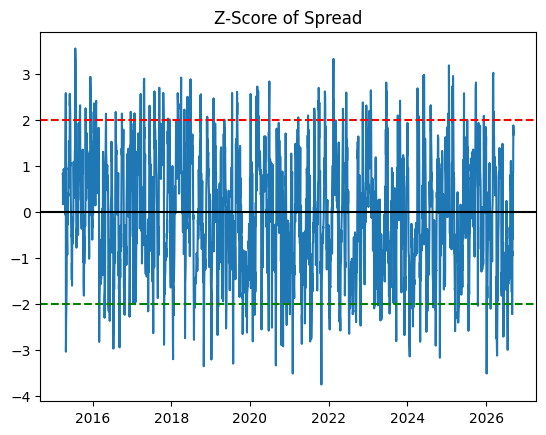

In [12]:
plt.plot(df["z_score"])
plt.axhline(y=2, color="red", linestyle="--")
plt.axhline(y=-2, color="green", linestyle="--")
plt.axhline(y=0, color="black", linestyle="-")
plt.title("Z-Score of Spread")
plt.savefig("Z-Score of Spread,png")
plt.show()

In [13]:
#z_score define how it work 
current_position = 0
position_list = []

for i in df["z_score"]:
    if current_position == 0 and i > 2:
        current_position = -1
    elif current_position == 0 and i < -2:
        current_position = 1
    elif current_position != 0 and i > -0.5 and i < 0.5:
        current_position = 0
    
    position_list.append(current_position)

df["position"] = position_list
    
    
    

    
        
        
        
    

In [14]:
print(df[["z_score", "position"]].head(100))

             z_score  position
Date                          
2015-03-02       NaN         0
2015-03-03       NaN         0
2015-03-04       NaN         0
2015-03-05       NaN         0
2015-03-09       NaN         0
...              ...       ...
2015-07-20  1.027332         0
2015-07-21  1.344207         0
2015-07-22  0.552123         0
2015-07-23  1.568455         0
2015-07-24  3.559920        -1

[100 rows x 2 columns]


In [15]:
#define position 
df["spread_change"] = df["spread"].diff()
df["daily_pnl"] = df["position"].shift(1) * df["spread_change"]




In [16]:
print(df[["spread_change", "position"]].head(100))

            spread_change  position
Date                               
2015-03-02            NaN         0
2015-03-03       0.748450         0
2015-03-04      -5.047242         0
2015-03-05       6.720264         0
2015-03-09      15.405480         0
...                   ...       ...
2015-07-20       3.450090         0
2015-07-21       2.403877         0
2015-07-22      -4.042914         0
2015-07-23       4.172589         0
2015-07-24      17.784382        -1

[100 rows x 2 columns]


In [17]:
#profit loss calcuation 
df["daily_pnl"] = df["position"].shift(1) * df["spread_change"]
df["cumulative_pnl"] = df["daily_pnl"].cumsum()
print(df[["spread_change", "position", "daily_pnl", "cumulative_pnl"]].head(50))





            spread_change  position  daily_pnl  cumulative_pnl
Date                                                          
2015-03-02            NaN         0        NaN             NaN
2015-03-03       0.748450         0   0.000000        0.000000
2015-03-04      -5.047242         0  -0.000000        0.000000
2015-03-05       6.720264         0   0.000000        0.000000
2015-03-09      15.405480         0   0.000000        0.000000
2015-03-10      -2.656744         0  -0.000000        0.000000
2015-03-11       2.297890         0   0.000000        0.000000
2015-03-12      -8.309464         0  -0.000000        0.000000
2015-03-13       8.696547         0   0.000000        0.000000
2015-03-16       0.219753         0   0.000000        0.000000
2015-03-17      -3.376962         0  -0.000000        0.000000
2015-03-18       1.305663         0   0.000000        0.000000
2015-03-19       3.995146         0   0.000000        0.000000
2015-03-20      17.329852         0   0.000000        0

In [18]:
df["transaction_cost"] = np.where(df["spread_change"], 0.0005 * abs(df["spread"]), 0)

In [19]:
df["position_changed"] = df["position"] != df["position"].shift(1)
df["position_changed"] = (df["position"] != df["position"].shift(1)).fillna(False)
print(df[["position", "position_changed"]].head(50))

            position  position_changed
Date                                  
2015-03-02         0              True
2015-03-03         0             False
2015-03-04         0             False
2015-03-05         0             False
2015-03-09         0             False
2015-03-10         0             False
2015-03-11         0             False
2015-03-12         0             False
2015-03-13         0             False
2015-03-16         0             False
2015-03-17         0             False
2015-03-18         0             False
2015-03-19         0             False
2015-03-20         0             False
2015-03-23         0             False
2015-03-24         0             False
2015-03-25         0             False
2015-03-26         0             False
2015-03-27         0             False
2015-03-30         0             False
2015-03-31         0             False
2015-04-01         0             False
2015-04-06         0             False
2015-04-07         0     

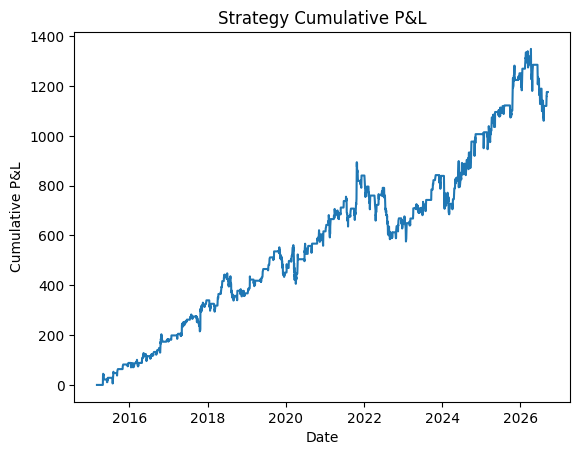

In [20]:
plt.plot(df["cumulative_pnl"])
plt.title("Strategy Cumulative P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L")
plt.savefig("Cumulative P&L.png")
plt.show()

In [21]:
#daily profit loss
df["net_daily_pnl"] = df["daily_pnl"] - df["transaction_cost"]
df["net_cumulative_pnl"] = df["net_daily_pnl"].cumsum()

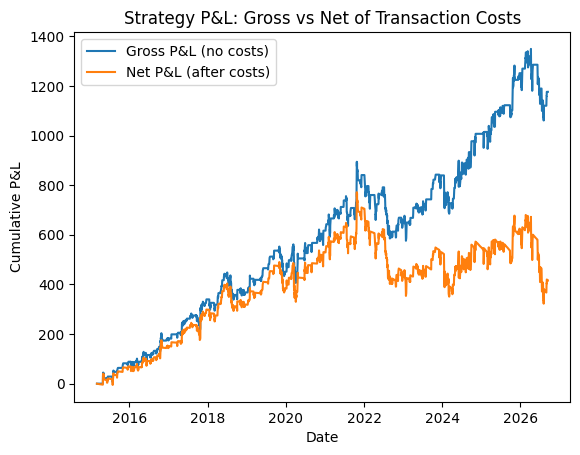

In [22]:
plt.plot(df["cumulative_pnl"], label="Gross P&L (no costs)")
plt.plot(df["net_cumulative_pnl"], label="Net P&L (after costs)")
plt.legend()
plt.title("Strategy P&L: Gross vs Net of Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L")
plt.savefig("gross vs net .png")
plt.show()

In [23]:
sharpe_ratio = (df["net_daily_pnl"].mean() / df["net_daily_pnl"].std()) * np.sqrt(252)
print(sharpe_ratio)

0.212308368072337


In [24]:
running_max = df["net_cumulative_pnl"].cummax()
drawdown = df["net_cumulative_pnl"] - running_max
max_drawdown = drawdown.min()
print(max_drawdown)

-449.15812642908816


In [25]:
num_trades = df["position_changed"].sum()
print(num_trades)
in_position_days = df[df["position"] != 0]
win_rate = (in_position_days["net_daily_pnl"] > 0).sum() / len(in_position_days)
print(win_rate)

241
0.431740614334471


In [26]:

position_meaning = {
    -1: "Short HDFC, Long ICICI",
     0: "No Position",
     1: "Long HDFC, Short ICICI"
}

df["position_meaning"] = df["position"].map(position_meaning)

print(df[["z_score", "position", "position_meaning"]].tail(1))

             z_score  position position_meaning
Date                                           
2026-09-14  1.685751         0      No Position
